<a href="https://colab.research.google.com/github/Guille-1905/Analisis_resultados_UNAM_2018-2026/blob/main/2_An%C3%A1lisis_exploratorio_de_los_resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2. Análisis exploratorio de resultados

##2.1 Objetivo
El presente notebook desarrolla un Análisis Exploratorio de Datos (EDA) sobre los resultados del proceso de admisión a licenciatura de la Universidad Nacional Autónoma de México (UNAM) correspondientes al periodo 2018–2026. El objetivo es caracterizar el comportamiento de los aciertos obtenidos por los aspirantes mediante el estudio de su distribución, tendencia central, dispersión y evolución temporal, así como identificar patrones y posibles anomalías entre los distintos años, áreas del conocimiento y carreras. Este análisis descriptivo busca comprender la estructura de los datos y generar evidencia que sirva como base para las pruebas estadísticas y el análisis inferencial desarrollados en las etapas posteriores del proyecto.   

----

##2.1 Carga de librerias y `Datasets`
Se hará uso de las bases de datos obtenidas al finalizar la `Preparación y validación de datos` descrito en el `notebook` anterior. De esta manera se garantiza la consistencia de la información almacenada en ambas bases de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

df_aspirantes = pd.read_parquet('https://github.com/Guille-1905/An-lisis_Resultados_UNAM_2026/raw/refs/heads/main/estadisticas_aspirantes_UNAM_corregido.parquet')
df_carreras = pd.read_parquet('https://github.com/Guille-1905/An-lisis_Resultados_UNAM_2026/raw/refs/heads/main/estadisticas_carreras_UNAM_corregido.parquet')

----
##2.2 Estadísticos descriptivos generales.
En esta sección se busca resumir el comportamiento de la variable `aciertos` haciendo uso de las medidas de tendendia central y dispersión con el fin de comprender la caracterización de los resultados de cada año.

<Figure size 900x700 with 0 Axes>

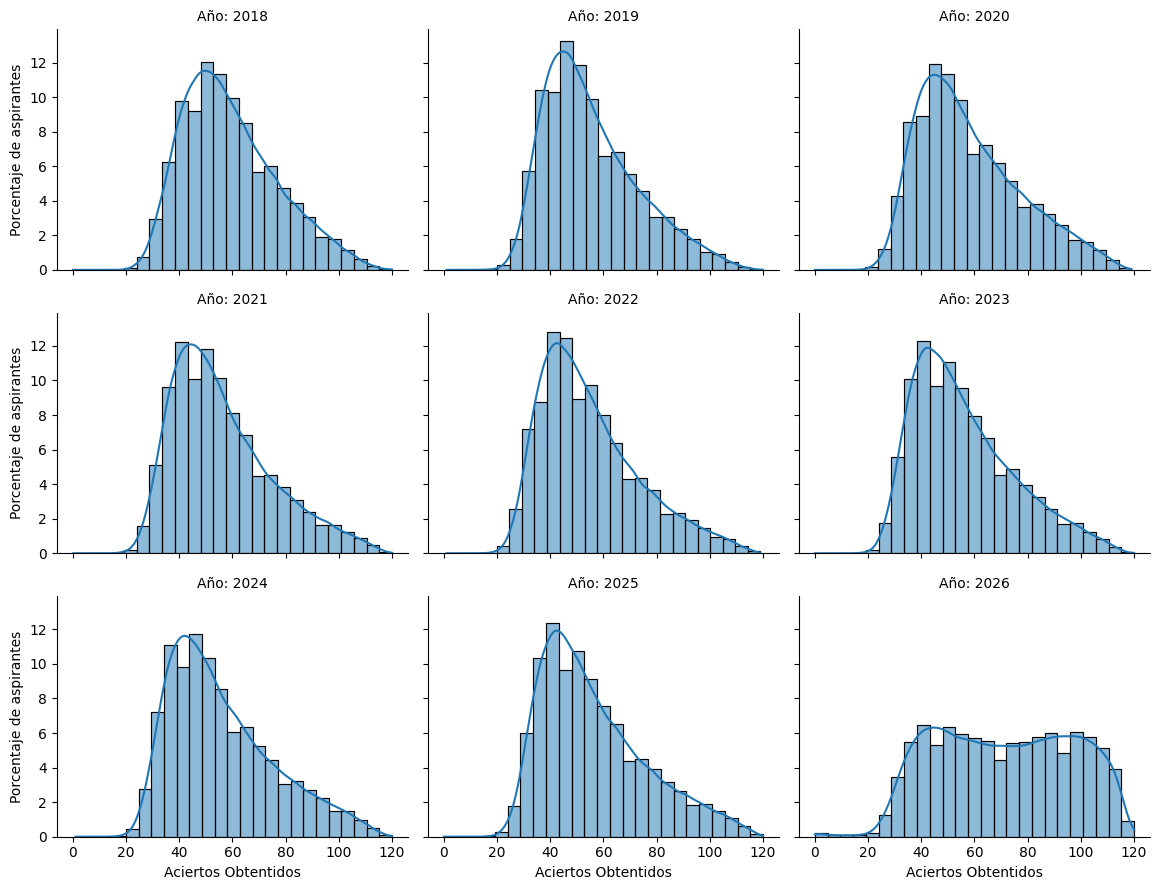

In [ ]:

#@title Distribución de aciertos por año.

plt.figure(figsize=(9, 7))

g = sns.FacetGrid(df_aspirantes, col='año', col_wrap=3, height=3, aspect=1.3)
figura_1 = g.map_dataframe(sns.histplot, x='aciertos', kde=True, bins=25, stat='percent')

figura_1.set_axis_labels("Aciertos Obtentidos", "Porcentaje de aspirantes")
figura_1.set_titles(col_template="Año: {col_name}")

plt.show(figura_1)

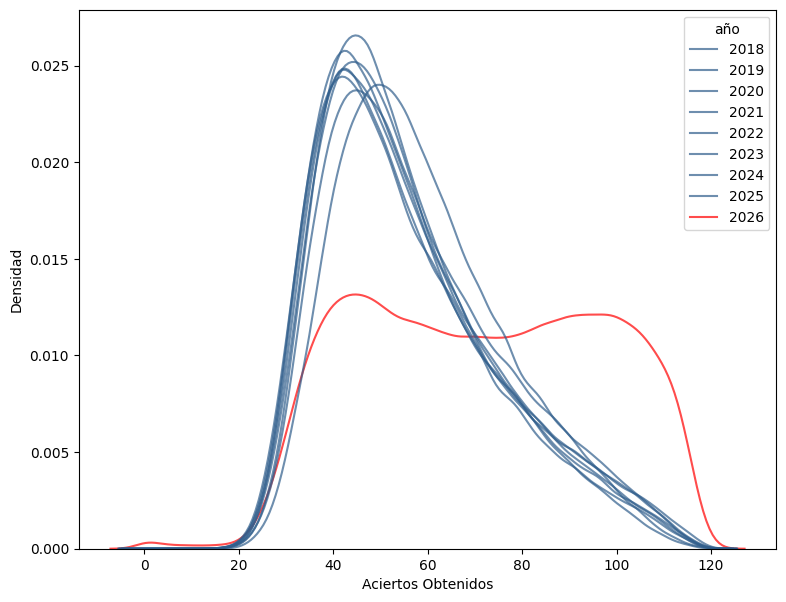

In [ ]:
import numpy as np
#@title Distribuciones superpuestas

plt.figure(figsize=(9, 7))

figura_2 = sns.kdeplot(data=df_aspirantes, x='aciertos', hue='año', fill=False, palette=["#305E8C"] * 8 + ["#FF0000"], common_norm=False, alpha=.7)

figura_2.set_xlabel("Aciertos Obtenidos")
figura_2.set_ylabel("Densidad")

plt.show(figura_2)

Las curvas de densidad evidencian una notable estabilidad en la distribución de los aciertos durante el periodo 2018–2025. En todos estos años se observa una distribución unimodal con una densidad alta localizada alrededor de los 45 aciertos y una asimetría positiva. Por el contrario, la distribución correspondiente a 2026 presenta una forma notablemente distinta, caracterizada por un menor grado de densidad alrededor del modo histórico y una segunda región de alta densidad en los puntajes altos, echo que no ocurre en el periodo 2018-2025.

----

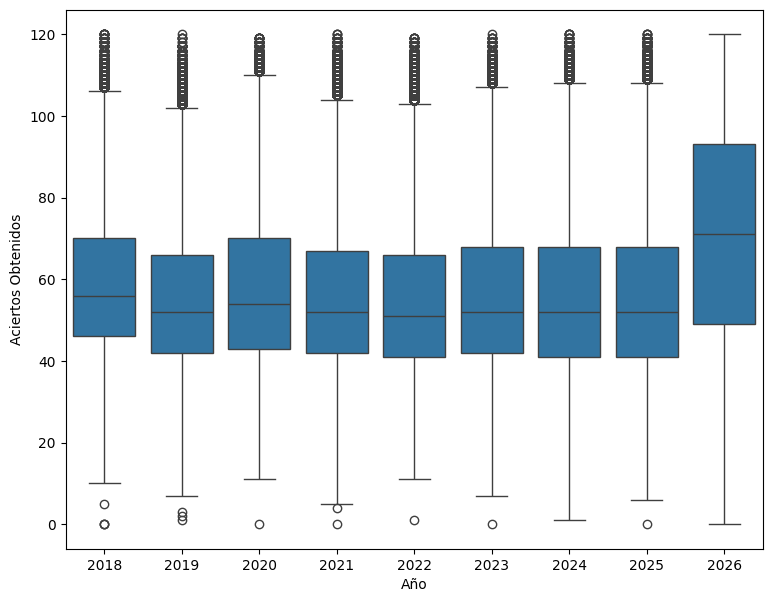

In [ ]:
#@title Distribución de aciertos mediante un diagrama de caja y bigote (Boxplot)

plt.figure(figsize=(9, 7))

figura_3 = sns.boxplot(data=df_aspirantes, x='año', y='aciertos')

figura_3.set_xlabel("Año")
figura_3.set_ylabel("Aciertos Obtenidos")

plt.show(figura_3)

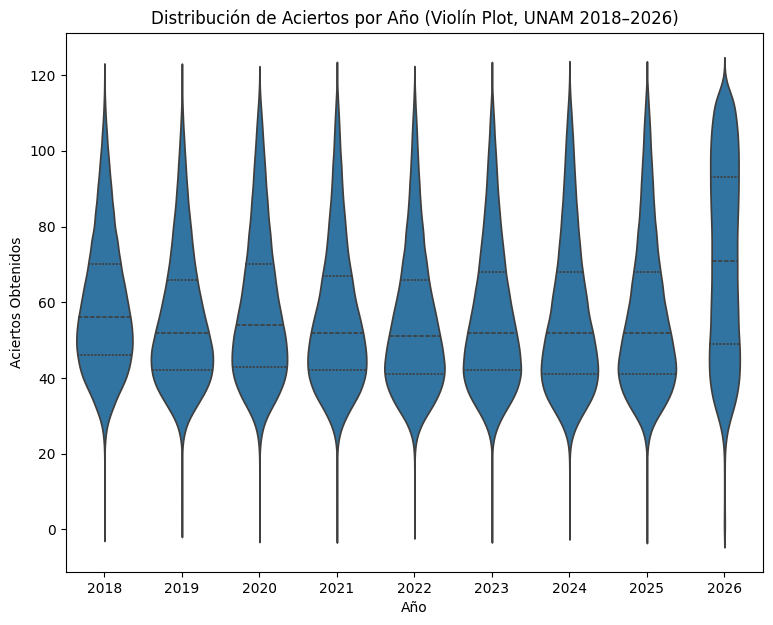

In [ ]:
#@title Distribución de aciertos por año mediante un diagrama de violín.

plt.figure(figsize=(9, 7))

figura_4 = sns.violinplot(data=df_aspirantes, x='año', y='aciertos', inner='quartile')

figura_4.set_xlabel("Año")
figura_4.set_ylabel("Aciertos Obtenidos")
figura_4.set_title("Distribución de Aciertos por Año (Violín Plot, UNAM 2018–2026)")

plt.show(figura_4)

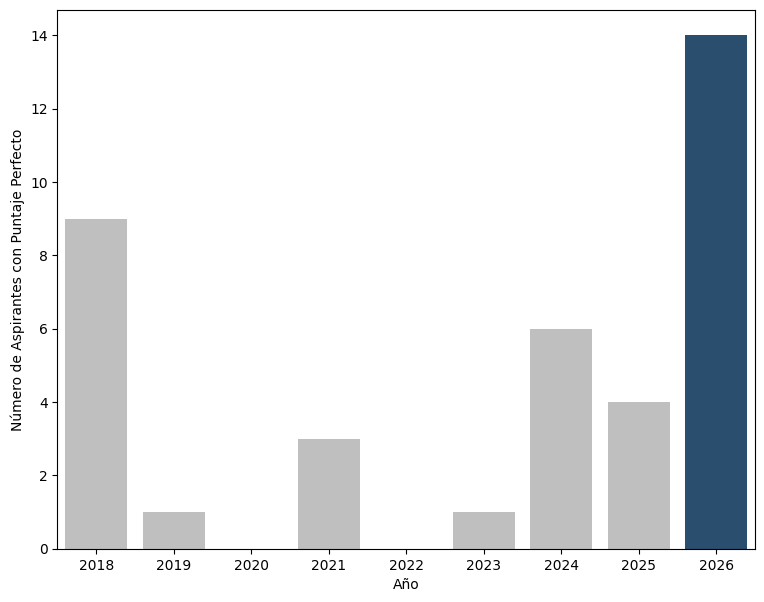

In [ ]:
#@title Aspirantes con puntaje perfecto por año

from matplotlib.ticker import PercentFormatter

años = np.sort(df_aspirantes['año'].unique())

puntajes_perfectos_por_año = (
    df_aspirantes[df_aspirantes["aciertos"] == 120]
    .groupby("año")
    .size()
    .reset_index(name="cantidad")
)

df_años = pd.DataFrame({'año': años})

puntaje_perfecto = pd.merge(df_años, puntajes_perfectos_por_año, on='año', how='left')
puntaje_perfecto['cantidad'] = puntaje_perfecto['cantidad'].fillna(0)

plt.figure(figsize=(9, 7))

figura_6 = sns.barplot(data=puntaje_perfecto, x='año', y='cantidad', hue='año', palette = ["#BFBFBF"]*8 + ["#1F4E79"], legend=False)

figura_6.set_xlabel("Año")
figura_6.set_ylabel("Número de Aspirantes con Puntaje Perfecto")

plt.show(figura_6)

El análisis conjunto del boxplot, el gráfico de violín y la evolución del número de puntajes perfectos permite identificar diferencias importantes entre el comportamiento observado en 2026 y el registrado durante el periodo 2018–2025. En primer lugar, al igual que las distribuciones ya observadas anteriormente el periodo 2018–2025 muestra una notable estabilidad tanto en su posición como en su dispersión. Las medianas permanecen en valores similares y el rango intercuartílico presenta variaciones relativamente pequeñas, lo que sugiere un comportamiento consistente de los resultados a lo largo de este periodo.

Por otro lado, la distribución correspondiente a 2026 presenta cambios importantes. La mediana experimenta un incremento considerable respecto a los años anteriores, ubicándose incluso en un nivel cercano al tercer cuartil de las distribuciones históricas. Esto indica que el puntaje obtenido por un aspirante "típico" en 2026 es comparable con los puntajes alcanzados por el 25 % de los aspirantes con mejores resultados en los procesos previos.

Un aspecto particularmente llamativo es la ausencia de valores atípicos en 2026. A diferencia de los años anteriores, donde los puntajes muy altos se consideran valores atípicos, en 2026 estos valores quedan comprendidos dentro del rango esperado de la distribución. Esto sugiere que los puntajes elevados dejaron de ser eventos excepcionales.

Finalmente, el incremento en el número de aspirantes que obtuvieron el puntaje máximo (120 aciertos) refuerza esta evidencia descriptiva. Mientras que entre 2018 y 2025 los puntajes perfectos fueron escasos, en 2026 su frecuencia aumenta de manera notable, lo cual es consistente con el desplazamiento de la distribución hacia valores altos observado en las gráficas anteriores.

----
##2.3 Estadísticos descriptivos por área de conocimiento
Una vez analizada la distribución de los aciertos de manera global, el siguiente paso consiste en estudiar su comportamiento por área de conocimiento. Este nivel de desagregación permite determinar si las diferencias observadas en el proceso de admisión 2026 corresponden a un fenómeno generalizado o si, por el contrario, se concentran en áreas académicas específicas.

La UNAM agrupa sus programas de licenciatura en cuatro grandes áreas del conocimiento: Área 1 (Ciencias Físico-Matemáticas e Ingenierías), Área 2 (Ciencias Biológicas, Químicas y de la Salud), Área 3 (Ciencias Sociales) y Área 4 (Humanidades y de las Artes). Para cada una de ellas se analizarán las distribuciones de aciertos obtenidos por los aspirantes y sus principales estadísticas descriptivas, con el objetivo de identificar posibles diferencias respecto al comportamiento histórico observado entre 2018 y 2025.

In [ ]:
#@title Densidades superpuestas por área de conocimientos. {run: "auto"}

def graficar_area_kde(area):
    datos_area = df_aspirantes[df_aspirantes["area"] == area]

    plt.figure(figsize=(8, 6))

    sns.kdeplot(data=datos_area, x='aciertos', hue='año', fill=False, palette=["#305E8C"] * 8 + ["#FF0000"], common_norm=False, alpha=.7)
    plt.xlabel("Aciertos Obtenidos")
    plt.ylabel("Densidad")
    plt.title(f"Distribución de Aciertos por Año — Área {area}")
    plt.show()

opciones_areas = sorted(df_aspirantes["area"].unique())

menu_areas = widgets.Dropdown(
    options=opciones_areas,
    description="Área:",
    disabled=False,
    style={"description_width": "initial"},
)

widgets.interactive(graficar_area_kde, area=menu_areas)

interactive(children=(Dropdown(description='Área:', options=(np.int64(1), np.int64(2), np.int64(3), np.int64(4…

Las curvas de densidad agrupadas por área, muestran la misma consistencia en las distribuciones dentro del periodo 2018-2025. Podemos observar una distribución unimodal con una alta concentración el rededor de 40 aciertos y una disminución de la densidad conforme las gráficas tieneden a los puntajes más altos. A pesar de existir ligeras variaciones entre cada año, la forma general de las distribuciones permanece prácticamente estable, lo que sugiere que el proceso de admisión se mantuvo relativamente constante en todas las áreas de conocimiento dentro del periodo 2018-2025.

Por el contrario, las densidades descritas por área en el 2026 muestran una variación notable. En cada caso se observa una disminución de la concentración alrededor del intervalo donde se concentraba el máximo de densidad histórico, acompañada de un incremento marcado alrededor de los puntajes más altos. Este aumento de densidad puede verse con mayor claridad en las distribuciones del área de las ciencias biológicas, químicas y de la salud (Área 2). En contraste con el área de humanidades y artes, pues a pesar de tener un incremento en la densidad cerca de los puntajes altos, no es tan drástica como en el resto de las áreas.

In [ ]:
#@title Distribución de aciertos por año y área mediante un diagrama de caja y bigote (Boxplot)

def graficar_boxplot_area(area):

    # Filtrar la información del área seleccionada
    datos_area = (
        df_aspirantes[
            df_aspirantes["area"] == area
        ]
        .dropna(subset=["año", "aciertos"])
        .copy()
    )

    if datos_area.empty:
        print("No existen datos para el área seleccionada.")
        return

    # Ordenar cronológicamente los años
    anios = sorted(datos_area["año"].unique())

    plt.figure(figsize=(13, 6))

    sns.boxplot(
        data=datos_area,
        x="año",
        y="aciertos",
        order=anios
    )

    plt.title(
        f"Distribución de aciertos por año — Área {area}",
        fontsize=16
    )

    plt.xlabel("Año")
    plt.ylabel("Aciertos")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

areas_disponibles = sorted(
    df_aspirantes["area"].dropna().unique()
)

selector_area_boxplot = widgets.Dropdown(
    options=areas_disponibles,
    value=areas_disponibles[0],
    description="Área:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

salida_boxplot = widgets.Output()


def actualizar_boxplot(cambio):
    with salida_boxplot:
        clear_output(wait=True)
        graficar_boxplot_area(cambio["new"])


selector_area_boxplot.observe(
    actualizar_boxplot,
    names="value"
)

display(selector_area_boxplot, salida_boxplot)

# Mostrar inicialmente la primera área
with salida_boxplot:
    graficar_boxplot_area(selector_area_boxplot.value)

Dropdown(description='Área:', layout=Layout(width='250px'), options=(np.int64(1), np.int64(2), np.int64(3), np…

Output()

Los diagramas de caja muestran una estabilidad relativa en la posición y dispersión de los resultados durante el periodo 2018–2025 en las cuatro áreas del conocimiento. En estos años, las medianas permanecen generalmente por debajo de los 60 aciertos y los rangos intercuartílicos presentan dimensiones similares, lo que indica que el 50 % central de los aspirantes mantuvo un comportamiento relativamente constante.

En contraste, durante 2026 se observa un desplazamiento de las distribuciones hacia puntajes más altos, acompañado de un incremento en la dispersión. En todas las áreas, la mediana de 2026 se aproxima o supera el nivel correspondiente al tercer cuartil de los años anteriores. Esto significa que el resultado típico de un aspirante en 2026 se encuentra cerca del nivel alcanzado históricamente por el 25 % de los aspirantes con mejores puntajes.

El cambio es particularmente visible en las Áreas 2 y 3, cuyas medianas en 2026 se sitúan alrededor de los 70–75 aciertos, mientras que en las Áreas 1 y 4 también se aprecia un incremento, aunque de menor magnitud. Asimismo, los rangos intercuartílicos de 2026 son considerablemente más amplios, lo que evidencia una mayor variabilidad de los resultados respecto al periodo histórico.

En conjunto, los boxplots sugieren que el comportamiento observado en 2026 no se limita a una sola área del conocimiento, sino que corresponde a un desplazamiento generalizado de los puntajes y a un aumento de su dispersión.

----

##2.4 Estadísticos descriptivos por carrera
El objetivo de esta sección es profundizar en el análisis descriptivo a nivel de carrera y plantel, con el propósito de identificar si las diferencias observadas en el análisis general también se presentan de manera particular en cada una de las licenciaturas ofertadas por la UNAM. Para ello, se estudiará el comportamiento de la distribución de aciertos de los aspirantes, así como la evolución de los puntajes mínimos de ingreso registrados entre 2018 y 2026.

Este análisis permitirá distinguir si los cambios observados en el proceso de admisión de 2026 corresponden a un fenómeno generalizado entre las distintas carreras o si se concentran únicamente en determinados programas académicos. Asimismo, se cuantificará la magnitud de dichos cambios mediante la comparación de estadísticas descriptivas e incrementos anuales en los puntajes mínimos de ingreso.

In [ ]:
#@title Tabla de comparación por carrera (Histórico vs 2026)

import unicodedata

def normalizar_texto(texto):
    texto = str(texto).strip().upper()

    # Elimina acentos
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter for caracter in texto
        if not unicodedata.combining(caracter)
    )

    # Elimina espacios repetidos
    texto = " ".join(texto.split())

    return texto

df_aspirantes["plantel"] = (
    df_aspirantes["plantel"]
    .apply(normalizar_texto)
)

df_aspirantes["carrera"] = (
    df_aspirantes["carrera"]
    .apply(normalizar_texto)
)


#Datos historicos (2018-2025)
historico = df_aspirantes[df_aspirantes["año"].between(2018, 2025)]

estadisticos_historicos = (
    historico.groupby(
        ["area", "carrera", "plantel"],
        observed=True
    )["aciertos"]
    .agg(
        media_historica="mean",
        mediana_historica="median",
        desviacion_historica="std",
        q1_historico=lambda x: x.quantile(.25),
        q3_historico=lambda x: x.quantile(.75),
        aspirantes_historicos="count"
    )
    .reset_index()
)


#Datos del 2026
datos_2026 = df_aspirantes[df_aspirantes["año"] == 2026]

estadisticos_2026 = (
    datos_2026
    .groupby(
        ["area", "carrera", "plantel"],
        observed=True
    )["aciertos"]
    .agg(
        media_2026="mean",
        mediana_2026="median",
        desviacion_2026="std",
        q1_2026=lambda x: x.quantile(.25),
        q3_2026=lambda x: x.quantile(.75),
        aspirantes_2026="count"
    )
    .reset_index()
)

comparacion = estadisticos_historicos.merge(
    estadisticos_2026,
    on=["area", "carrera", "plantel"],
    how="inner"
)

comparacion["Δ_media"] = (
    comparacion["media_2026"]
    - comparacion["media_historica"]
)

comparacion["Δ_mediana"] = (
    comparacion["mediana_2026"]
    - comparacion["mediana_historica"]
)

comparacion["Δ_desviacion"] = (
    comparacion["desviacion_2026"]
    - comparacion["desviacion_historica"]
)

comparacion["Δ_q1"] = comparacion["q1_2026"] - comparacion["q1_historico"]

comparacion["Δ_q3"] = comparacion["q3_2026"] - comparacion["q3_historico"]

comparacion

,area,carrera,plantel,media_historica,mediana_historica,desviacion_historica,q1_historico,q3_historico,aspirantes_historicos,media_2026,mediana_2026,desviacion_2026,q1_2026,q3_2026,aspirantes_2026,Δ_media,Δ_mediana,Δ_desviacion,Δ_q1,Δ_q3
0,1,ACTUARIA,FACULTAD DE CIENCIAS,68.850627,66.0,20.881703,52.0,85.0,10524,81.794682,86.0,24.035219,63.00,103.00,1354,12.944055,20.0,3.153515,11.00,18.00
1,1,ACTUARIA,FES ACATLAN,63.600074,61.0,19.690097,48.0,77.0,5411,76.561538,79.0,23.801375,56.00,97.75,650,12.961465,18.0,4.111278,8.00,20.75
2,1,ARQUITECTURA,FACULTAD DE ARQUITECTURA,56.845257,53.0,18.701624,42.0,69.0,37152,70.875857,71.0,25.017811,49.00,93.00,3939,14.030599,18.0,6.316188,7.00,24.00
3,1,ARQUITECTURA,FES ACATLAN,50.631915,47.0,15.429723,39.0,59.0,12057,65.753215,64.0,23.208822,46.00,85.00,1244,15.121300,17.0,7.779099,7.00,26.00
4,1,ARQUITECTURA,FES ARAGON,50.223044,47.0,15.039773,39.0,59.0,15275,66.450405,65.0,23.595541,45.00,87.00,1603,16.227361,18.0,8.555768,6.00,28.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,4,PEDAGOGIA,FES ARAGON,47.395119,45.0,13.846304,37.0,55.0,16471,60.545858,58.0,22.117397,42.00,79.00,1352,13.150739,13.0,8.271093,5.00,24.00
171,4,PIANO,FACULTAD DE MUSICA,60.798587,58.0,19.286890,45.5,75.0,283,73.000000,70.0,20.104988,62.25,87.75,20,12.201413,12.0,0.818098,16.75,12.75
172,4,TEATRO Y ACTUACION,FACULTAD DE MUSICA,56.791007,54.0,17.254849,43.0,68.0,5493,63.916071,63.0,20.855541,48.00,80.00,560,7.125065,9.0,3.600692,5.00,12.00
173,4,TRADUCCION,ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD LEON,68.400000,66.0,16.951498,55.5,80.5,215,65.571429,69.0,16.065799,54.50,77.00,14,-2.828571,3.0,-0.885699,-1.00,-3.50


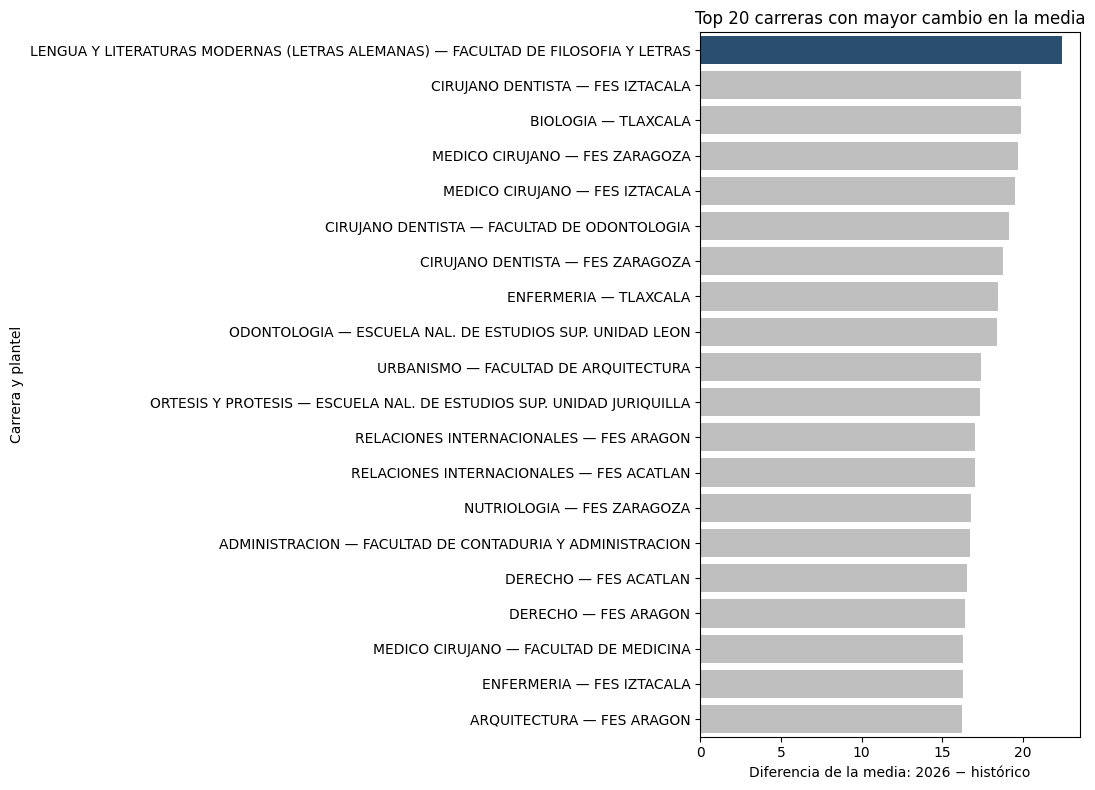

In [ ]:
#@title Top 20 carreras con mayor cambio en la media de aciertos (2026 vs promedio histórico 2018-2025)

comparacion["carrera_plantel"] = (comparacion["carrera"] + " — " + comparacion["plantel"])

top_20 = (
    comparacion
    .nlargest(20, "Δ_media")
    .sort_values("Δ_media", ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=top_20,
    x="Δ_media",
    y="carrera_plantel",
    hue="carrera_plantel",
    legend=False,
    palette = ["#1F4E79"] + ["#BFBFBF"]*19,
    errorbar=None,
    ax=ax
)

ax.set_title("Top 20 carreras con mayor cambio en la media")
ax.set_xlabel("Diferencia de la media: 2026 − histórico")
ax.set_ylabel("Carrera y plantel")

plt.tight_layout()
plt.show()

El análisis de las medias por combinación carrera–plantel muestra que el incremento observado en 2026 no fue uniforme entre todos los programas académicos. Algunas carreras experimentaron desplazamientos considerablemente mayores que otras, alcanzando incrementos superiores a 20 aciertos respecto a su comportamiento histórico (2018–2025).

Destaca particularmente la Licenciatura en Lengua y Literaturas Modernas (Letras Alemanas), impartida en la Facultad de Filosofía y Letras, cuya media aumentó aproximadamente 23 aciertos. Asimismo, carreras del área de Ciencias Biológicas, Químicas y de la Salud, como Médico Cirujano, Cirujano Dentista, Enfermería, Nutriología y Odontología, aparecen repetidamente entre los mayores incrementos observados.

La presencia de múltiples programas de alta demanda dentro de los primeros lugares sugiere que el desplazamiento de la distribución de los puntajes en 2026 fue especialmente pronunciado en determinadas carreras, más allá del incremento general identificado en el análisis global.

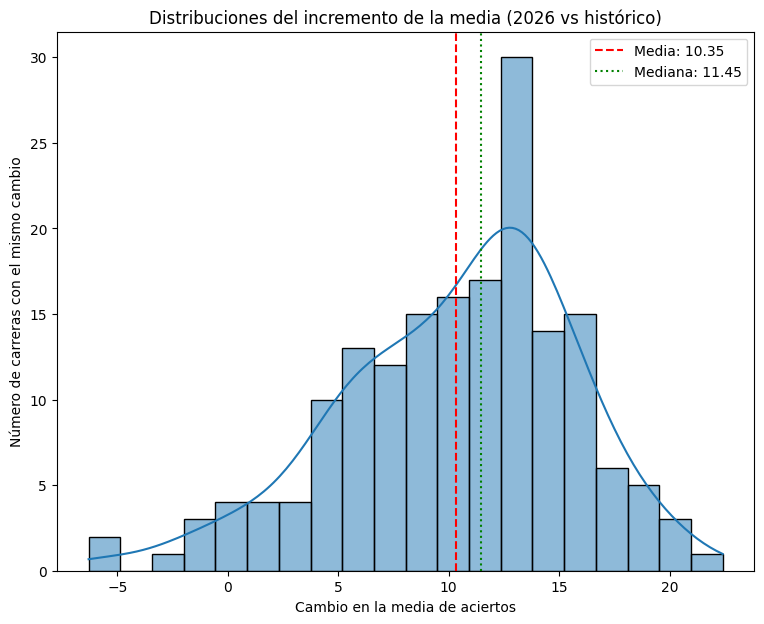

In [ ]:
#@title Distribución del incremento de la media de aciertos.

carreras_por_media = comparacion.groupby('Δ_media').size().reset_index(name='carrera_con_mismo_cambio')

fig, ax = plt.subplots(figsize=(9, 7))

sns.histplot(data=carreras_por_media, x='Δ_media', bins=20, kde=True, ax=ax)

media_incremento = comparacion["Δ_media"].mean()
mediana_incremento = comparacion["Δ_media"].median()

ax.axvline(media_incremento, color='red', linestyle='--', label=f'Media: {media_incremento:.2f}')
ax.axvline(mediana_incremento, color='green', linestyle=':', label=f'Mediana: {mediana_incremento:.2f}')

ax.legend()

ax.set_xlabel("Cambio en la media de aciertos")
ax.set_ylabel("Número de carreras con el mismo cambio")
ax.set_title("Distribuciones del incremento de la media (2026 vs histórico)")

plt.show()

La distribución de cambios de la media de aciertos muestra que el desplazamiento observado en el año 2026 no fue un evento aislado en grupo reducido de carreras, si no que, fue un fenomeno ampliamente distribuido entre las carreras. Podemos observar que a pasear de existir carreras con una disminución de aciertos, la mayor densidad se úbica alrededor de los +13 y +15 aciertos en la media. Esto aumenta la evidencia de que el comportamiento observado en 2026 corresponde a un cambio sistemático en la distribución de los aciertos, más que a variaciones aisladas en programas específicos.

In [ ]:
#@title Cambio en el puntaje mínimo de ingreso por carrera.

minimos_por_año = df_carreras.pivot_table(
    index=["area", "carrera", "plantel"],
    columns="año",
    values="aciertos_minimos",
).reset_index()

columnas_años = list(range(2018, 2027))

diferencias_por_año = minimos_por_año[columnas_años].diff(axis=1)
diferencias_por_año = diferencias_por_año.iloc[:, 1:]

diferencias_por_año.columns = [
    "Δ18-19",
    "Δ19-20",
    "Δ20-21",
    "Δ21-22",
    "Δ22-23",
    "Δ23-24",
    "Δ24-25",
    "Δ25-26"
]

diferencias_por_año = pd.concat([minimos_por_año[['area', 'carrera', 'plantel']], diferencias_por_año], axis=1)
diferencias_por_año

,area,carrera,plantel,Δ18-19,Δ19-20,Δ20-21,Δ21-22,Δ22-23,Δ23-24,Δ24-25,Δ25-26
0,1,ACTUARIA,FACULTAD DE CIENCIAS,-0.5,3.0,-2.0,-2.0,-4.0,6.0,2.0,4.0
1,1,ACTUARIA,FES ACATLAN,0.0,2.5,-3.0,-5.0,-6.0,7.0,3.0,11.0
2,1,ARQUITECTURA,FACULTAD DE ARQUITECTURA,-2.0,3.0,-3.5,-1.0,0.0,5.0,1.0,12.0
3,1,ARQUITECTURA,FES ACATLAN,-0.5,7.0,-10.0,0.0,0.0,0.0,-1.0,22.0
4,1,ARQUITECTURA,FES ARAGON,-2.0,4.0,-5.0,-1.0,1.0,2.0,2.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...
183,4,PEDAGOGIA,FES ARAGON,-5.5,9.0,-9.5,3.0,3.0,1.0,-3.0,22.0
184,4,PIANO,FACULTAD DE MUSICA,-0.5,-4.5,-7.5,-3.0,1.0,-1.0,10.0,-7.0
185,4,TEATRO Y ACTUACION,FACULTAD DE MUSICA,-4.0,5.0,-5.0,0.0,-1.0,-3.0,-1.0,-3.0
186,4,TRADUCCION,ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD LEON,<NA>,<NA>,9.0,12.0,-27.0,0.0,3.0,-5.0


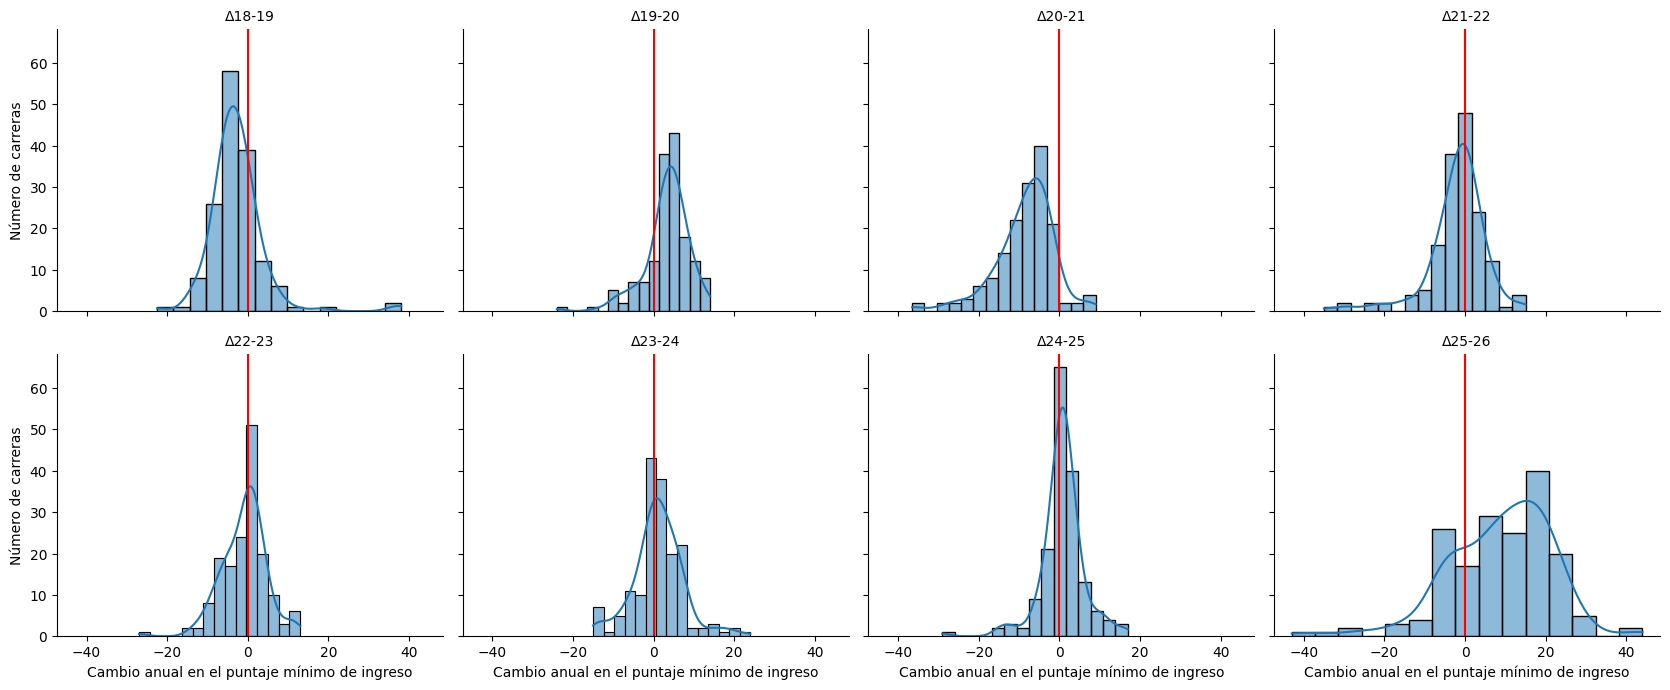

In [ ]:
#@title Distribución del cambio de aciertos mínimos por año.

incrementos_long = diferencias_por_año.melt(
    id_vars=["area", "carrera", "plantel"],
    value_vars=[
        "Δ18-19","Δ19-20","Δ20-21","Δ21-22",
        "Δ22-23","Δ23-24","Δ24-25","Δ25-26"
    ],
    var_name="periodo",
    value_name="incremento"
)

g = sns.FacetGrid(data=incrementos_long, col='periodo', col_wrap=4,height=3.5,aspect=1.2)
g.map_dataframe(sns.histplot,x="incremento",bins=15,kde=True)
for ax in g.axes.flat:
    ax.axvline(0,color="red",linestyle="-",linewidth=1.5)

g.set_axis_labels("Cambio anual en el puntaje mínimo de ingreso","Número de carreras")
g.set_titles("{col_name}")


plt.show()


La distribución del cambio anual en el puntaje mínimo de ingreso, durenate el periodo 2018-2025, muestra que los cambios anuales se concentraban normalmente alrededor del cero, lo que nos dice que generalmente las variaciones de un año a otro fueron relativamente pequeñas. A pesar de que existen variaciones considerables en ese periodo, estas corresponden a un número reducido de carreras y no modifican el comportamiento general de la distribución.

En contraste con el 2026, podemos ver una mayor concentración de la densidad en los valores postivos cercanos a +20 aciertos. Dado que este comportamiento no tiene antecedentes comparables en el periodo 2018-2025 nos muestra evidencia de que el poceso del 2026 presenta un patrón estadísticamente distinto al observado historicamente.

----
##2.5 Conclusión del análisis exploratorio
El análisis exploratorio realizado sobre los resultados del examen de admisión de licenciatura de la UNAM correspondientes al periodo 2018–2026 permite identificar un cambio consistente en el comportamiento de los puntajes obtenidos durante el proceso de admisión de 2026.

Después de analizar el comportamiento de los aciertos de manera general (por año) y manera perticular (por área y carrera) podemos concluir que el proceso llevado a cabo en el 2026 existe un comportamiento estadísticamente diferente a lo registrado en el periodo histórico. Se observa un cambio marcado en las distribuciones de los aciertos, esto pues, en el periodo histórico la concentración de los resultados por alumno se ubicaba alrededor de los 40 aciertos, mientras que en el 2026 se observó una mayor densidad al rededor de los puntajes altos.

El análisis por áreas de conocimiento indica que este fenómeno no se limita a una disciplina en particular, sino que está presente en las cuatro áreas académicas evaluadas, aunque con distinta intensidad. De manera similar, el análisis a nivel de carrera muestra que el incremento en los puntajes no corresponde únicamente a un reducido conjunto de programas académicos, sino que afecta a una proporción considerable de las combinaciones carrera–plantel. Sin embargo, se pudo observar que el promedio de aciertos por carrera aumentaba principalmente en carreras del área de las ciencias biológicas, químicas y de la salud (Área 2).

En conjunto, la evidencia descriptiva presentada en este capítulo sugiere que el proceso de admisión 2026 exhibe un comportamiento atípico respecto al patrón histórico observado durante los ocho años anteriores.